In [19]:
import os
import pickle
import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import scikit_posthocs as sp
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from mlflow.models.signature import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance, XGBRFClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import friedmanchisquare
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from aeon.visualisation import plot_critical_difference

import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

'n_estimators': hp.quniform('n_estimators', 100, 300, 50),
    'max_depth': hp.choice('max_depth', [None, 10, 20]),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 2),
    'max_features': hp.choice('max_features', ['sqrt', 'log2']),
    'bootstrap': hp.choice('bootstrap', [True, False])

Best universal params: {'n_estimators': 250, 'max_depth': np.int64(1), 'min_samples_split': 10, 'max_features': np.int64(1), 'bootstrap': np.int64(0)}

In [20]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/'

In [21]:
# Random Forest with hyperparameter tuned parameters
rf_params = {
    'n_estimators': 250,
    'max_depth': 10,
    'min_samples_split': 10,
    'max_features': 'log2',
    'random_state': 42,
    'bootstrap': False
    }

rf_model = RandomForestClassifier(**rf_params)

In [22]:
params = rf_model.get_params()
params

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 250,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [23]:
def log_experiment_run(
    model,
    X_test,
    report_dict,
    # loss_fig_path,
    # cm_fig_path,
    # data_path,
    params,
    experiment_name="RandomForest Tuned Parameters",
    model_name="RandomForest"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']
    # del params['smote']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        # Extract individual class metrics (you can rename 'void' and 'non-void' if your class names are different)
        accuracy = report_dict.get("accuracy", 0.0)
        precision_void = report_dict.get("void", {}).get("precision", 0.0)
        recall_void = report_dict.get("void", {}).get("recall", 0.0)
        f1_void = report_dict.get("void", {}).get("f1-score", 0.0)

        precision_non_void = report_dict.get("non-void", {}).get("precision", 0.0)
        recall_non_void = report_dict.get("non-void", {}).get("recall", 0.0)
        f1_non_void = report_dict.get("non-void", {}).get("f1-score", 0.0)


        mlflow.log_metrics({

            # Void class (e.g., posture change)
            "precision_void": precision_void,
            "recall_void": recall_void,
            "f1_void": f1_void,

            # Non-void class
            "precision_non_void": precision_non_void,
            "recall_non_void": recall_non_void,
            "f1_non_void": f1_non_void,
            "accuracy": accuracy
        }) # type: ignore

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test[:1]
        signature = infer_signature(X_test, model.predict(X_test))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)

Accuracy: 71.18%
Accuracy: 69.79%
Accuracy: 69.61%
Accuracy: 69.09%
Accuracy: 70.14%
Accuracy: 69.25%
Accuracy: 67.30%
Accuracy: 69.30%
Accuracy: 68.88%
Accuracy: 67.95%
Accuracy: 70.13%
Accuracy: 67.84%
Accuracy: 68.55%
Accuracy: 70.37%
Accuracy: 69.18%


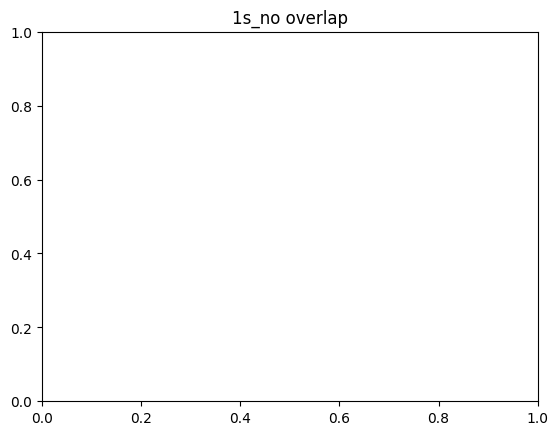

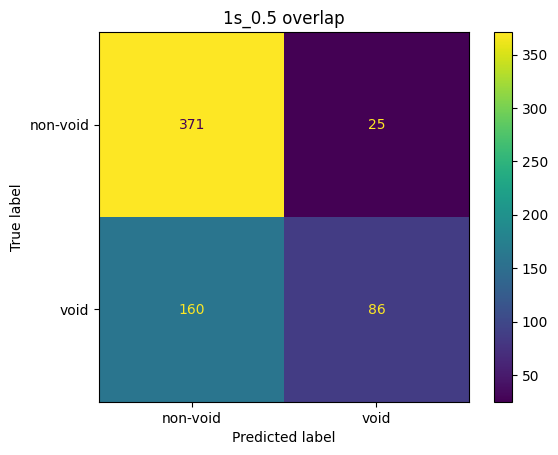

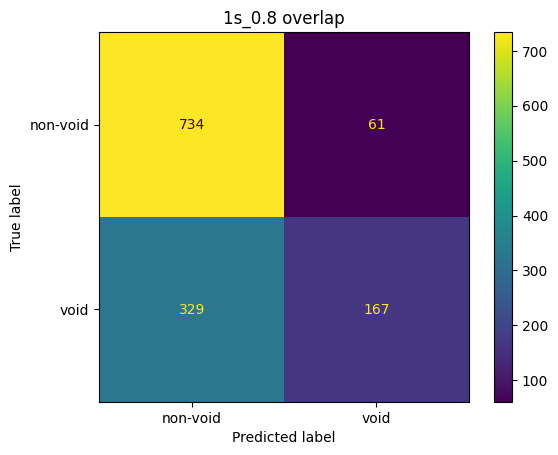

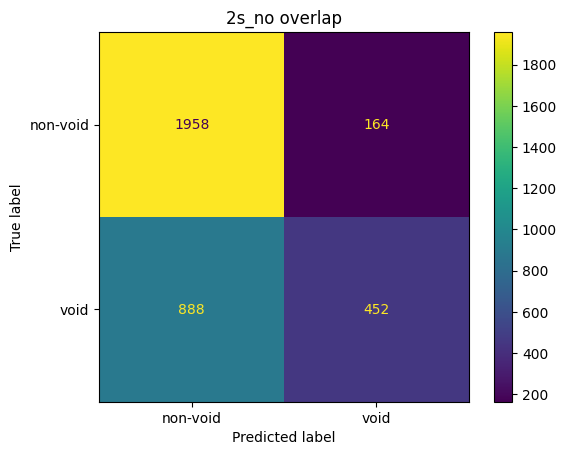

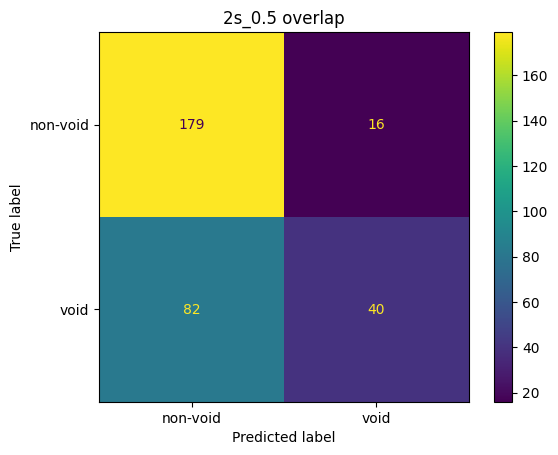

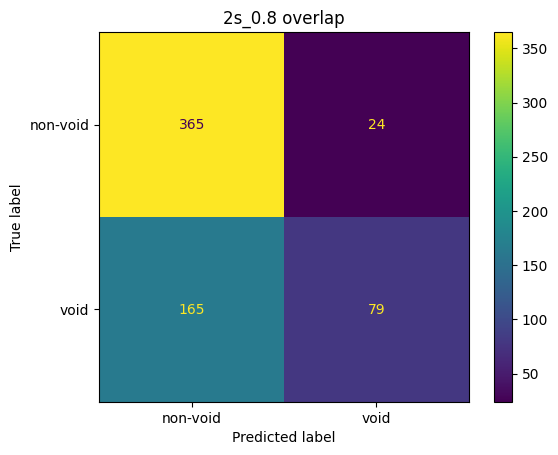

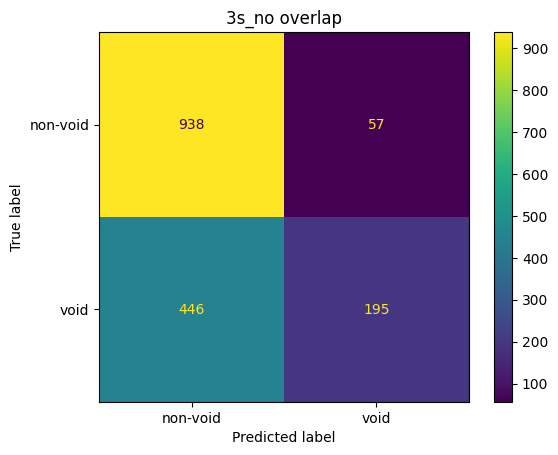

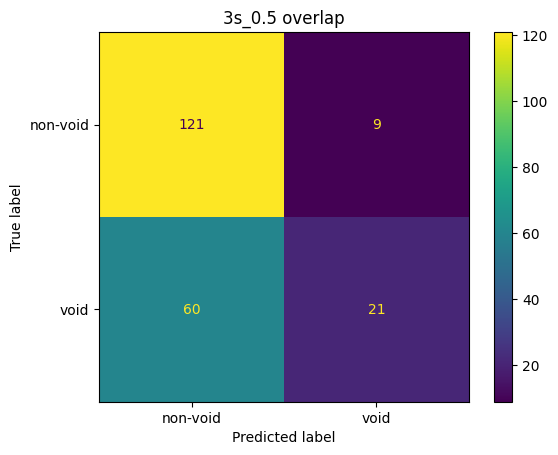

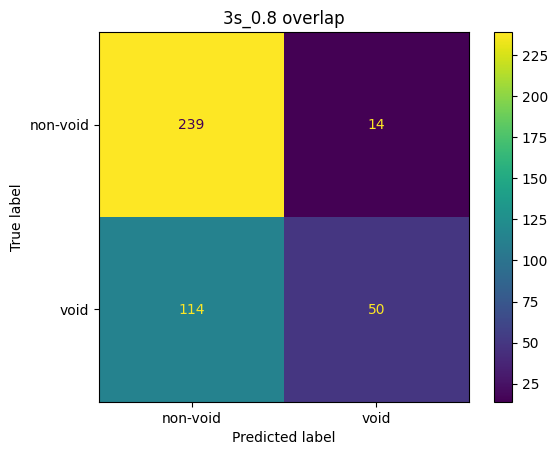

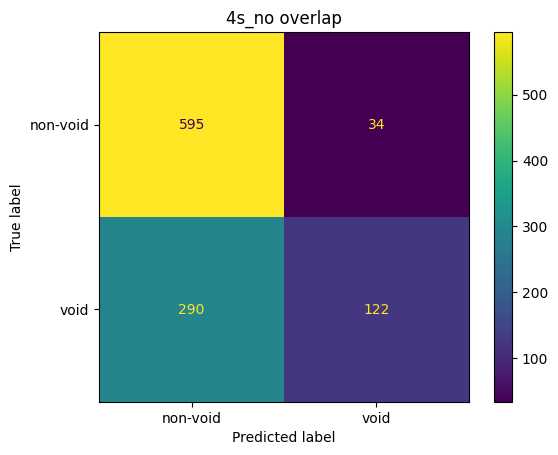

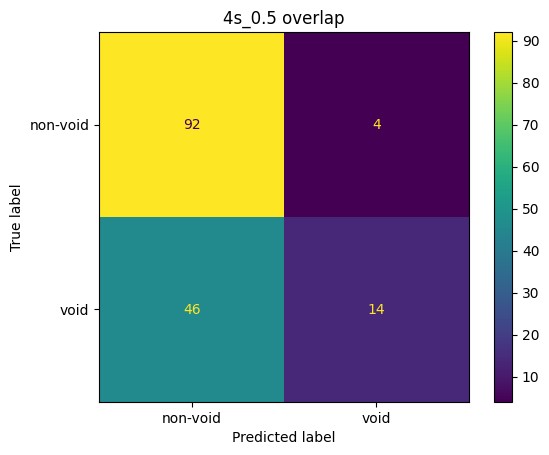

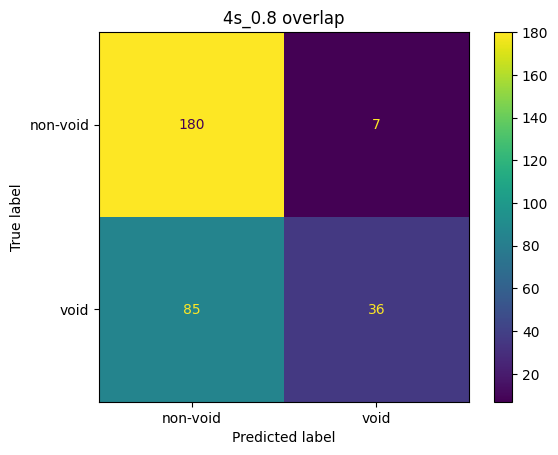

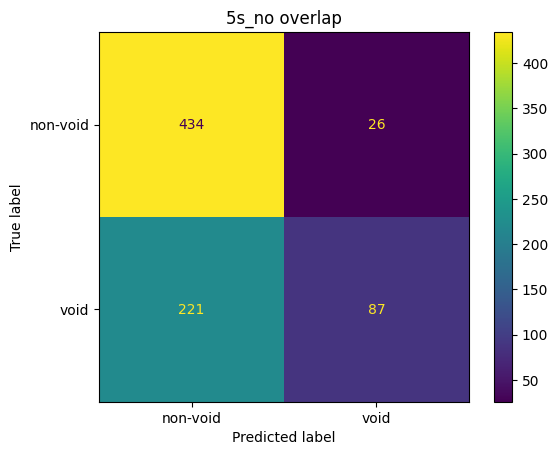

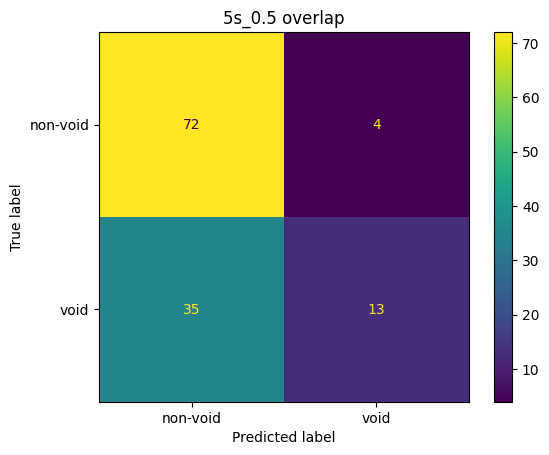

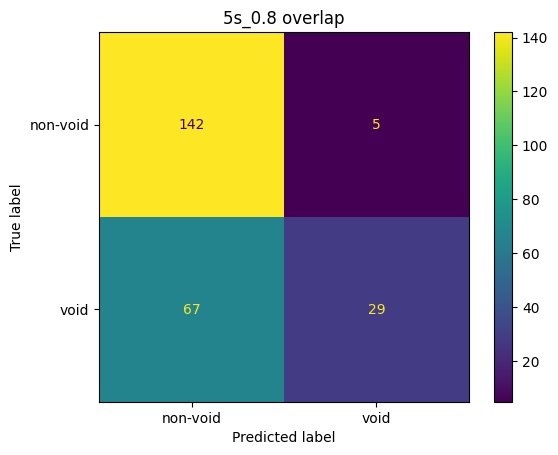

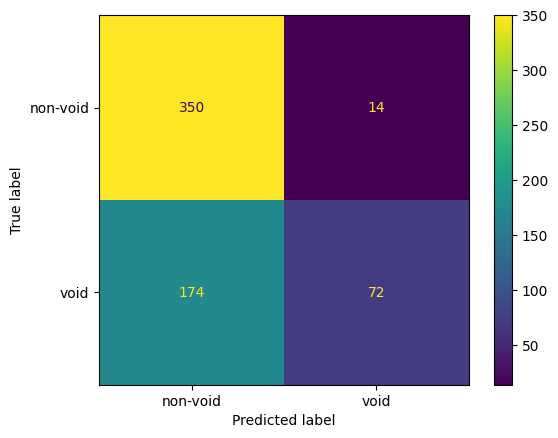

In [ ]:
for file in files:
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    details = file.split('_')
    exp_name = f"{details[3]}_{details[-1].replace('.csv', '')}"
    
    
    # Extracting the experiment_id from the filename
    details = file.split('_')
    win_overlap = f"{details[3]}_{details[-1].replace('.csv', '')}"
    
    # Split features and labels    
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']

    # Split the data into training and testing sets  
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]
    
    # Encode labels
    label_encoder = LabelEncoder()
    # Encode y_test and y_train
    y_train_encoded = label_encoder.fit_transform(y_train) 
    y_test_encoded = label_encoder.transform(y_test)
    
    # Train the model
    rf_model.fit(X_train, y_train_encoded)
    
    predictions = label_encoder.inverse_transform(rf_model.predict(X_test))
    accuracy = accuracy_score(y_test, predictions)
    print("Accuracy: %.2f%%" % (accuracy * 100.0))
    
    report = classification_report(y_test, predictions)
    
    # save plots
    cm = confusion_matrix(y_test, predictions)
    cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['non-void', 'void'])
    cm_fig_path = f"/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/randomforest/first_hypertuning/cm_{exp_name}.png"
    plt.title(f'{exp_name} overlap')
    cm_fig.plot()
    plt.savefig(cm_fig_path)
    


    overlap = details[-1].replace('.csv', '')
    win_size = int(details[3].split('s')[0])
    overlap = float(overlap if overlap != 'no' else 0.0)

    
    params = rf_model.get_params()
    params['window_size'] = win_size
    params['overlap'] = overlap
    params['exp_name'] = exp_name
    
    # Log the model
    log_experiment_run(
        model=rf_model,
        X_test=X_test,
        report_dict=classification_report(y_test, predictions, output_dict=True),
        params=params,
        # experiment_name=f"RandomForest Default - {exp_name}",
        # model_name="RandomForest"
    )
    